# **Salary Prediction** | 2025

# **I. Data Understanding**

# ***A. Penjabaran Studi Kasus***

yang harus dilakukan :
1. jadiin salary_in_usd jadi ada low, medium, high, very high (**dan hapus salary_currency**)
2. bikin fitur baru : same_country (employee_residence == company_location), is_remote (remote_ratio > 0), is_senior (experience_level = SE/EX)

# ***B. Import Libraries***

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tkinter as tk

# ***C. Import Dataset***

In [3]:
dataset = pd.read_csv("Dataset salary 2024.csv")
dataset

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2024,SE,FT,AI Engineer,202730,USD,202730,US,0,US,M
1,2024,SE,FT,AI Engineer,92118,USD,92118,US,0,US,M
2,2024,SE,FT,Data Engineer,130500,USD,130500,US,0,US,M
3,2024,SE,FT,Data Engineer,96000,USD,96000,US,0,US,M
4,2024,SE,FT,Machine Learning Engineer,190000,USD,190000,US,0,US,M
...,...,...,...,...,...,...,...,...,...,...,...
16529,2020,SE,FT,Data Scientist,412000,USD,412000,US,100,US,L
16530,2021,MI,FT,Principal Data Scientist,151000,USD,151000,US,100,US,L
16531,2020,EN,FT,Data Scientist,105000,USD,105000,US,100,US,S
16532,2020,EN,CT,Business Data Analyst,100000,USD,100000,US,100,US,L


# **II. Data Preparation**

# ***A. Exploratory Data Analysis***

### 1. Inspeksi Daftar Variabel

In [4]:
dataset.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='str')

penjelasan variabel :
1. work_year = tahun karyawan bekerja
2. experiance_level = karyawan ada di level berapa pengalamannya dalam bekerja
3. employment_type = karyawan bekerja penuh waktu atau paruh waktu
4. job_title = jabatan karayawan
5. salary_currency = mata uang gaji
6. salary_in_usd = gaji yang dikonversi ke dolar as
7. employee_residence = karyawan tinggal dimana
8. remote_ratio = 0% artinya kerja di rumah
9. company_location = perusahaan karyawan berada di mana

### 2. Inspeksi Informasi Ringkas

In [5]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 16534 entries, 0 to 16533
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   work_year           16534 non-null  int64
 1   experience_level    16534 non-null  str  
 2   employment_type     16534 non-null  str  
 3   job_title           16534 non-null  str  
 4   salary              16534 non-null  int64
 5   salary_currency     16534 non-null  str  
 6   salary_in_usd       16534 non-null  int64
 7   employee_residence  16534 non-null  str  
 8   remote_ratio        16534 non-null  int64
 9   company_location    16534 non-null  str  
 10  company_size        16534 non-null  str  
dtypes: int64(4), str(7)
memory usage: 1.4 MB


### 3. Inspeksi Statistik Deskriptif

In [6]:
dataset.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,16534.000000,1.653400e+04,16534.000000,16534.000000
mean,2023.226866,1.637270e+05,149686.777973,32.003750
std,0.713558,3.402057e+05,68505.293156,46.245158
min,2020.000000,1.400000e+04,15000.000000,0.000000
25%,2023.000000,1.017630e+05,101125.000000,0.000000
50%,2023.000000,1.422000e+05,141300.000000,0.000000
75%,2024.000000,1.872000e+05,185900.000000,100.000000
max,2024.000000,3.040000e+07,800000.000000,100.000000


### 4. Inspeksi Data NaN

In [7]:
dataset.isna().sum()

work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

### 5. Inspeksi Data Duplicated

In [8]:
dataset.duplicated().sum()

np.int64(6421)

### 7. Feature Engineering

#### *a. Encode*

In [9]:
dataset = dataset.drop_duplicates().reset_index(drop=True)
map_experience = {"EN": 0, "MI": 1, "SE": 2, "EX": 3}
map_type = {"FT": 0, "CT": 1, "PT": 2, "FL": 3}
map_companysize = {"S": 0, "M": 1, "L": 2}

dataset['experience_level'] = dataset['experience_level'].map(map_experience)
dataset['employment_type'] = dataset['employment_type'].map(map_type)
dataset['company_size'] = dataset['company_size'].map(map_companysize)

#### *b. Hapus salary_currency*

In [10]:
dataset = dataset.drop(columns=['salary_currency'])

#### *c. salary_category (**target**)*

In [11]:
def categorize_salary(salary):
    if salary < 50000:
        return 0 # low
    elif salary < 150000:
        return 1 # medium
    elif salary < 250000:
        return 2 # high
    else:
        return 3 # very high

dataset['salary_category'] = dataset['salary_in_usd'].apply(categorize_salary)
dataset['salary_category']

0        2
1        1
2        1
3        1
4        2
        ..
10108    3
10109    2
10110    1
10111    1
10112    1
Name: salary_category, Length: 10113, dtype: int64

#### *d. same_country*

In [12]:
dataset['same_country'] = (dataset['employee_residence'] == dataset['company_location'])
dataset['same_country']

0        True
1        True
2        True
3        True
4        True
         ... 
10108    True
10109    True
10110    True
10111    True
10112    True
Name: same_country, Length: 10113, dtype: bool

#### *e. is_remote*

In [13]:
dataset['is_remote'] = (dataset['remote_ratio'] > 0).astype(int)
dataset['is_remote']

0        0
1        0
2        0
3        0
4        0
        ..
10108    1
10109    1
10110    1
10111    1
10112    1
Name: is_remote, Length: 10113, dtype: int64

#### *f. is_senior*

In [14]:
dataset['is_senior'] = (dataset['experience_level'] >= 2).astype(int)
dataset['is_senior']

0        1
1        1
2        1
3        1
4        1
        ..
10108    1
10109    0
10110    0
10111    0
10112    1
Name: is_senior, Length: 10113, dtype: int64

#### *g. job_grouped*

In [15]:
top_jobs = dataset['job_title'].value_counts().head(10).index
dataset['job_grouped'] = dataset['job_title'].apply(lambda x: x if x in top_jobs else 'Other')
dataset['job_grouped'] = dataset.groupby('job_grouped')['salary_category'].transform('mean')
dataset['job_grouped']

0        1.387627
1        1.387627
2        1.454940
3        1.454940
4        1.798942
           ...   
10108    1.494278
10109    1.387627
10110    1.494278
10111    1.387627
10112    1.387627
Name: job_grouped, Length: 10113, dtype: float64

#### *h. hapus kolom asli yang sudah di encode*

In [16]:
dataset = dataset.drop(columns=[
    'job_title',
    'employee_residence',
    'company_location',
    'job_grouped',
    'salary_in_usd'  # opsional: bisa dihapus karena sudah jadi salary_category
])

### 8. Univariate Analysis

In [17]:
target_count = dataset['salary_category'].value_counts()
target_count

salary_category
1    5264
2    3605
3     779
0     465
Name: count, dtype: int64

#### *a. Inspeksi Distribusi Kelas Target*

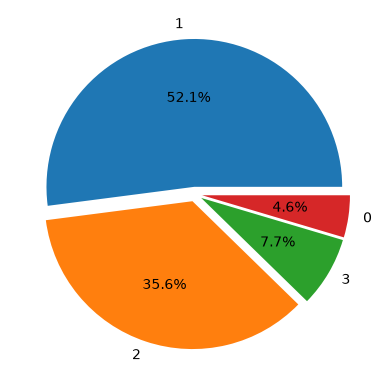

<Figure size 1000x1000 with 0 Axes>

In [18]:
def target_dist(target_counts):
    explode = [0.05] * len(target_count)
    plt.pie(target_count, labels=target_count.index, explode=explode, autopct="%1.1f%%")
    plt.figure(figsize=(10,10))
    plt.show()

target_dist(target_count)

#### *b. Inspeksi Distribusi Kelas Fitur*

In [19]:
current_cols = dataset.columns.tolist()
all_cols = [col for col in current_cols if col != "salary_category"]

def check_value(dataset, cols, top_n=10):
    for col in cols:
        print(dataset[col].value_counts().head(top_n))

check_value(dataset, all_cols)

work_year
2023    4632
2024    4074
2022    1116
2021     216
2020      75
Name: count, dtype: int64
experience_level
2    5950
1    2761
0    1011
3     391
Name: count, dtype: int64
employment_type
0    10033
2       38
1       28
3       14
Name: count, dtype: int64
salary
100000    166
150000    154
120000    144
80000     116
200000    114
110000    112
130000    111
70000     111
140000    111
90000     110
Name: count, dtype: int64
remote_ratio
0      6394
100    3472
50      247
Name: count, dtype: int64
company_size
1    9284
2     642
0     187
Name: count, dtype: int64
same_country
True     9983
False     130
Name: count, dtype: int64
is_remote
0    6394
1    3719
Name: count, dtype: int64
is_senior
1    6341
0    3772
Name: count, dtype: int64


### 9. Bivariate Analysis

In [20]:
target_col = ['salary_category']

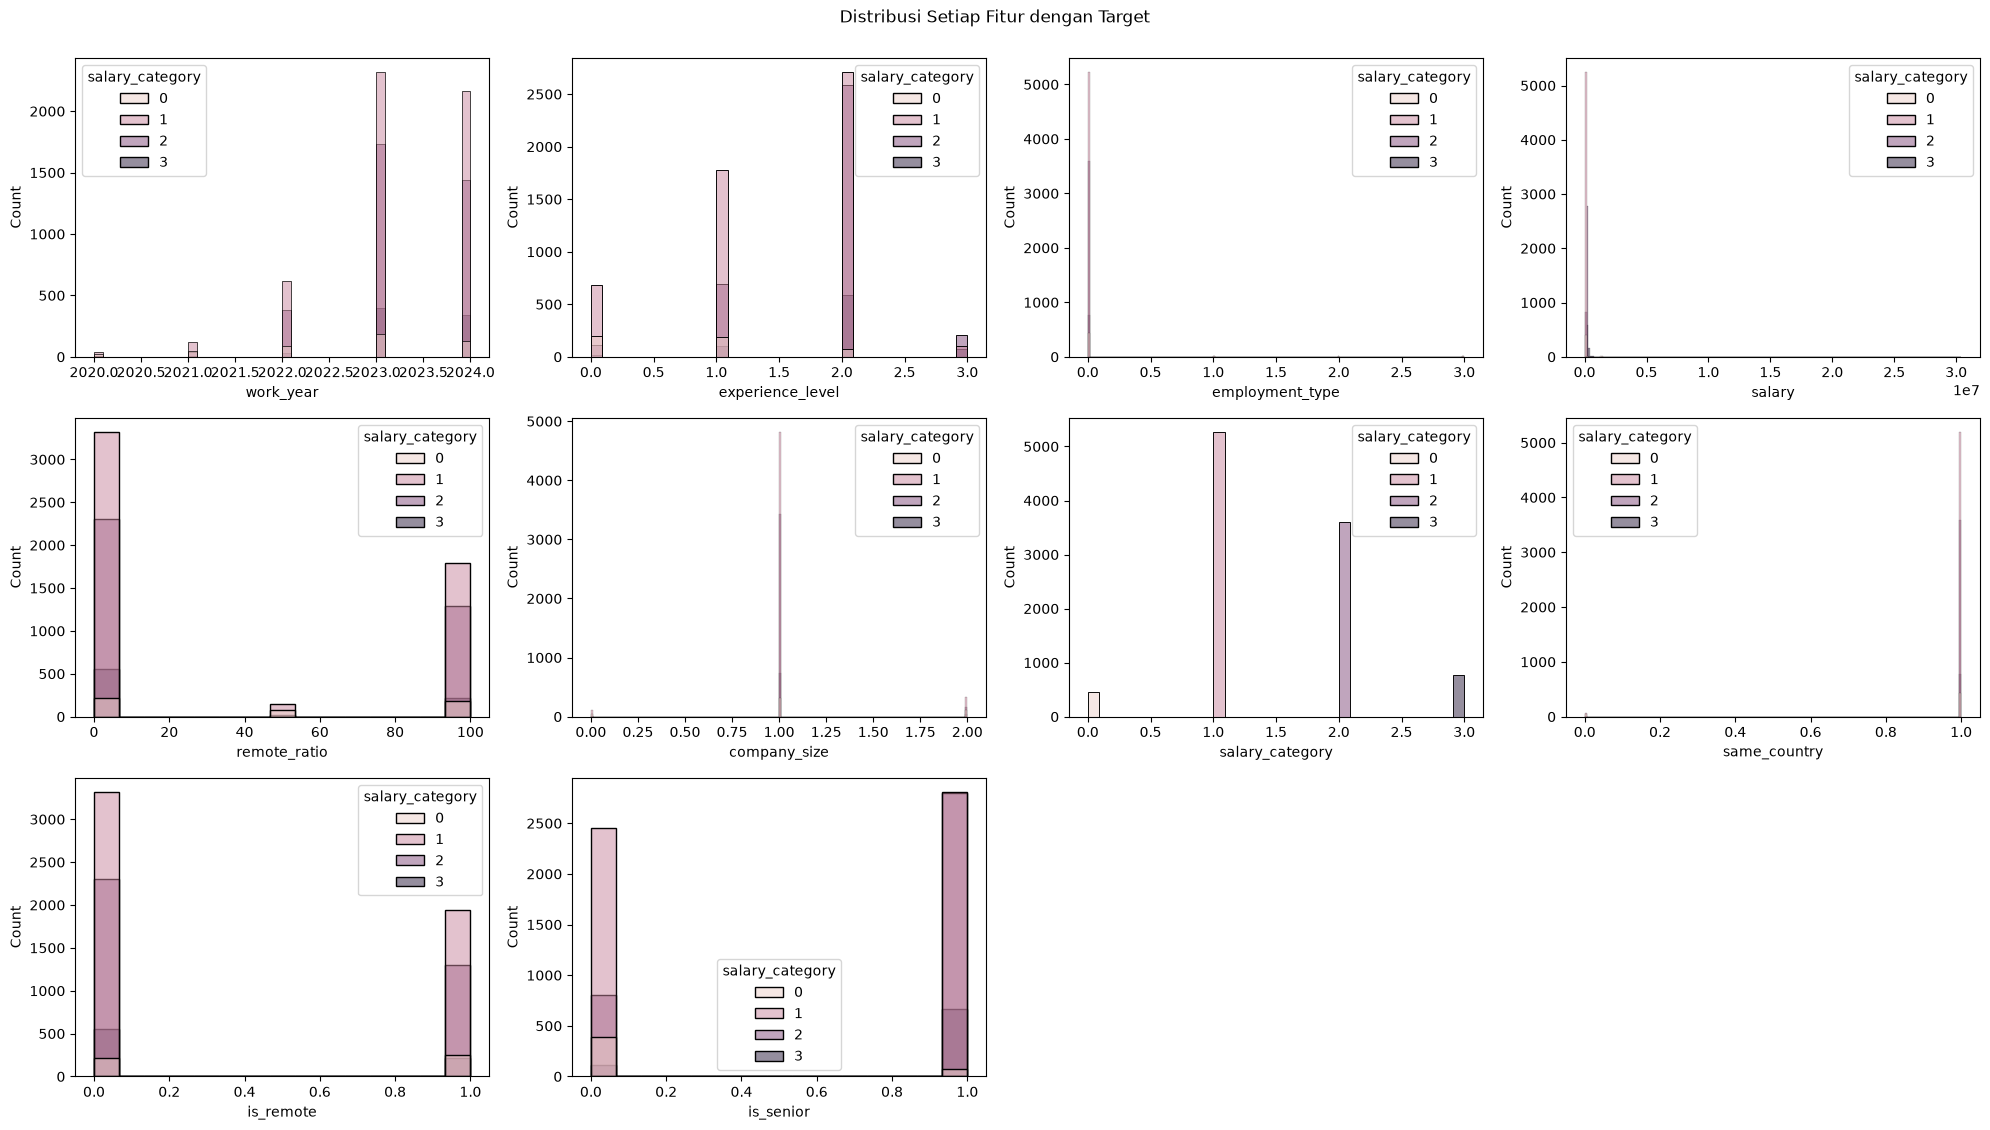

In [21]:
def hist_plot(p, l, dataset, target_col, p_col, l_col, title):
    plt.figure(figsize=(20,18))
    for i, col in enumerate(dataset):
        plt.subplot(5, 4, i+1)
        sns.histplot(x=dataset[col], hue=dataset['salary_category'])
    plt.suptitle("Distribusi Setiap Fitur dengan Target", y=1.001)
    plt.tight_layout()
    plt.show()

hist_plot(20, 18, dataset, target_col, 4, 5, "Distribusi Setiap Fitur dengan Target Duplicated")

### 10. Multivariate Analysis

In [22]:
# sns.pairplot(data=dataset, hue='salary_category')

### 11. Inspeksi Korelasi

#### *a. Mutual Information*

In [23]:
def probability_distribution(x):
    unique, counts = np.unique(x, return_counts=True)
    return counts / counts.sum()

def calculate_entropy(x):
    probs = probability_distribution(x)
    return -np.sum(probs * np.log2(probs + 1e-10))

def mutual_information(x, y):
    xy_pairs = list(zip(x, y))
    unique_xy, counts_xy = np.unique(xy_pairs, return_counts=True)
    probs_xy = counts_xy / counts_xy.sum()
    entropy_xy = -np.sum(probs_xy * np.log2(probs_xy + 1e-10))
    entropy_x = calculate_entropy(x)
    entropy_y = calculate_entropy(y)
    return entropy_x + entropy_y - entropy_xy

def mi_result(p, l, fitur, target, title):
    fitur = dataset[all_cols]
    target = dataset['salary_category']
    mi_scores = {col: mutual_information(fitur[col].values, target.values) for col in fitur.columns}
    mi_df = pd.DataFrame(list(mi_scores.items()), columns=['Feature', 'Mutual Information'])
    mi_df = mi_df.sort_values(by="Mutual Information", ascending=False)

    plt.figure(figsize=(12,8))
    sns.barplot(data=mi_df, x="Mutual Information", y="Feature", palette="magma")
    plt.xlabel("Mutual Information")
    plt.ylabel("Feature")
    plt.title("Mutual Information")
    plt.legend()
    plt.show()

C:\Users\nizam\AppData\Local\Temp\ipykernel_640\1156326187.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mi_df, x="Mutual Information", y="Feature", palette="magma")
C:\Users\nizam\AppData\Local\Temp\ipykernel_640\1156326187.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


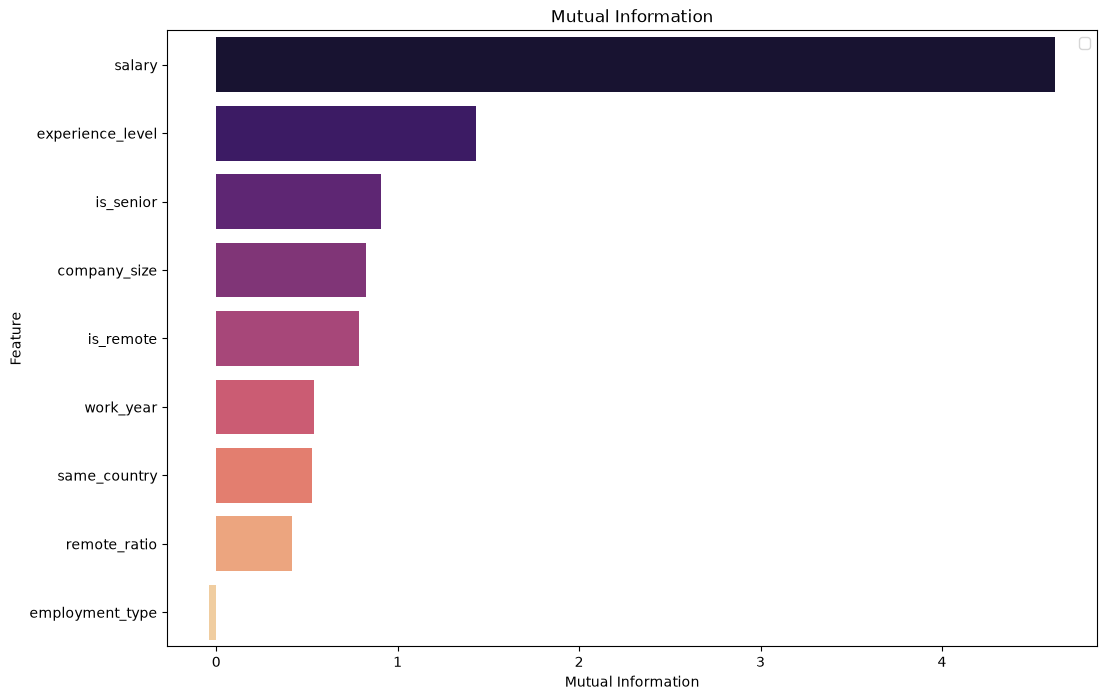

In [24]:
mi_result(12, 8, dataset[all_cols], dataset[target_col], "Mutual Information Duplicated")

#### *b. Method Chi Square*

In [25]:
num_cols = ['employment_type', 'same_country', 'is_remote', 'is_senior', 'work_year', 'remote_ratio']

In [26]:
def chi_square(data, col1, col2):
    observed = pd.crosstab(data[col1], data[col2])
    totals = observed.values.sum()
    row_totals = observed.sum(axis=1).values.reshape(-1, 1)
    col_totals = observed.sum(axis=0).values.reshape(1, -1)

    expected = row_totals @ col_totals / totals
    chi_square = ((observed.values - expected) ** 2 / expected).sum()

    return chi_square

def cs_result(p, l, dataset, all_cols, title):
    chi_scores = []

    for col in num_cols:
        chi = chi_square(dataset, col, 'salary_category')
        chi_scores.append((col, chi))

    chi_df = pd.DataFrame(chi_scores, columns=['Feature', 'Chi Scores'])
    chi_df = chi_df.sort_values(by="Chi Scores", ascending=False)

    plt.figure(figsize=(12, 8))
    sns.barplot(data=chi_df, x="Feature", y="Chi Scores")
    plt.show()

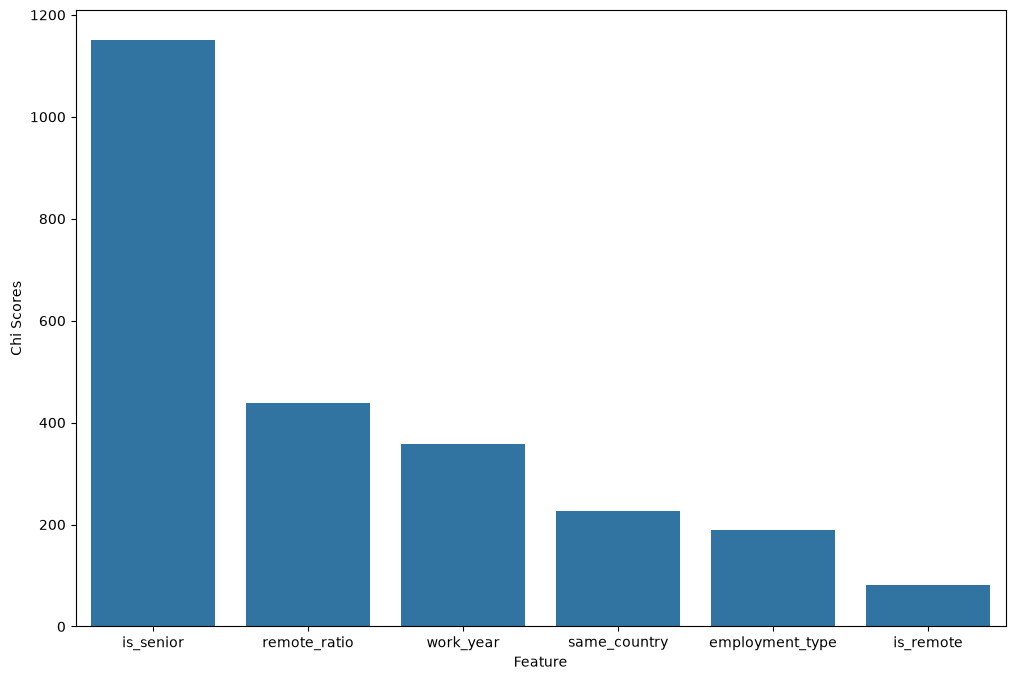

In [27]:
cs_result(15, 8, dataset, all_cols, "Chi Square Duplicated")

### 12. Inspeksi Outlier

<Axes: xlabel='salary_category', ylabel='work_year'>

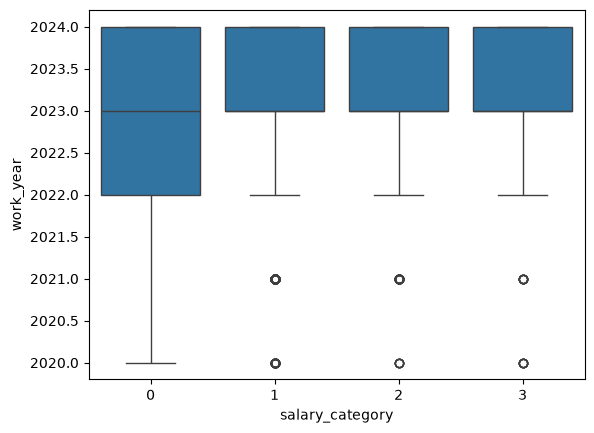

In [28]:
sns.boxplot(data=dataset, x='salary_category', y='work_year')

# ***B. Feature Selection***

In [29]:
feature_cols = [
    'experience_level',
    'company_size',
    'is_senior',
    'is_remote',
    'work_year',
    'same_country',
    'remote_ratio'
]

# ***C. Data Preprocessing***

### 1. Handling Duplicate

In [30]:
dataset_clean = dataset.copy()
dataset_clean = dataset_clean.drop_duplicates()
dataset_clean

,work_year,experience_level,employment_type,salary,remote_ratio,company_size,salary_category,same_country,is_remote,is_senior
0,2024,2,0,202730,0,1,2,True,0,1
1,2024,2,0,92118,0,1,1,True,0,1
2,2024,2,0,130500,0,1,1,True,0,1
3,2024,2,0,96000,0,1,1,True,0,1
4,2024,2,0,190000,0,1,2,True,0,1
...,...,...,...,...,...,...,...,...,...,...
10108,2020,2,0,412000,100,2,3,True,1,1
10109,2021,1,0,151000,100,2,2,True,1,0
10110,2020,0,0,105000,100,0,1,True,1,0
10111,2020,0,1,100000,100,2,1,True,1,0


#### *a. Univariate Analysis Clean*

In [31]:
target_count_clean = dataset_clean['salary_category'].value_counts()
target_count_clean

salary_category
1    3171
2    2014
3     552
0     395
Name: count, dtype: int64

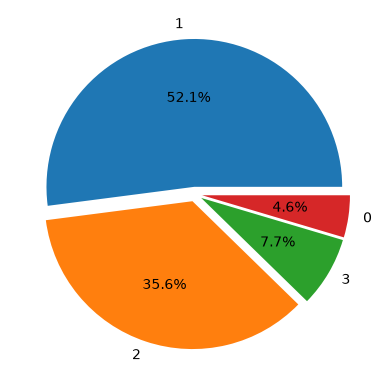

<Figure size 1000x1000 with 0 Axes>

In [32]:
target_dist(target_count_clean)

#### *b. Bivariate Analysis Clean*

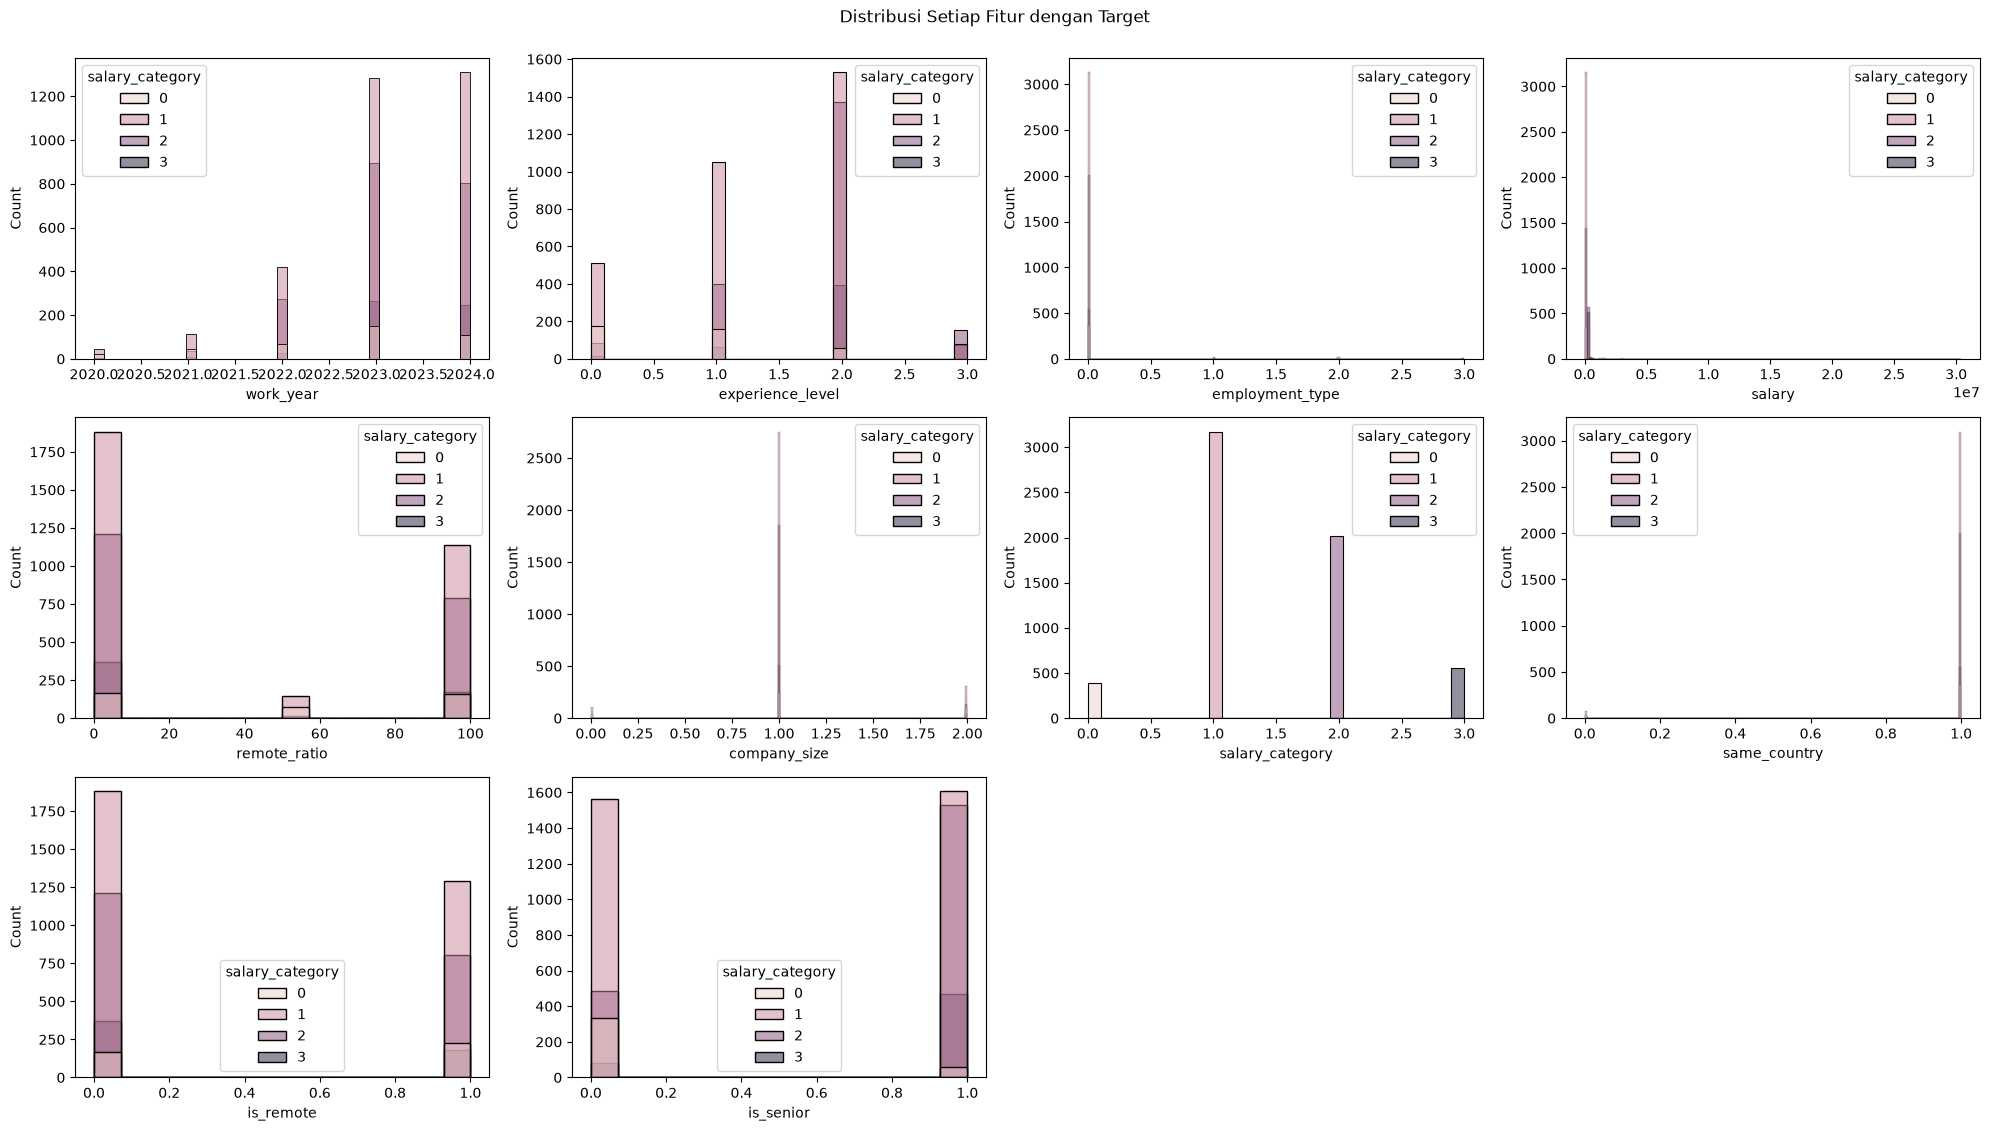

In [33]:
hist_plot(20, 18, dataset_clean, target_col, 4, 5, "Distribusi Setiap Fitur dengan Target No Duplicated")

#### *c. Inspeksi Korelasi Clean*

##### Mutual Information

C:\Users\nizam\AppData\Local\Temp\ipykernel_640\1156326187.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mi_df, x="Mutual Information", y="Feature", palette="magma")
C:\Users\nizam\AppData\Local\Temp\ipykernel_640\1156326187.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


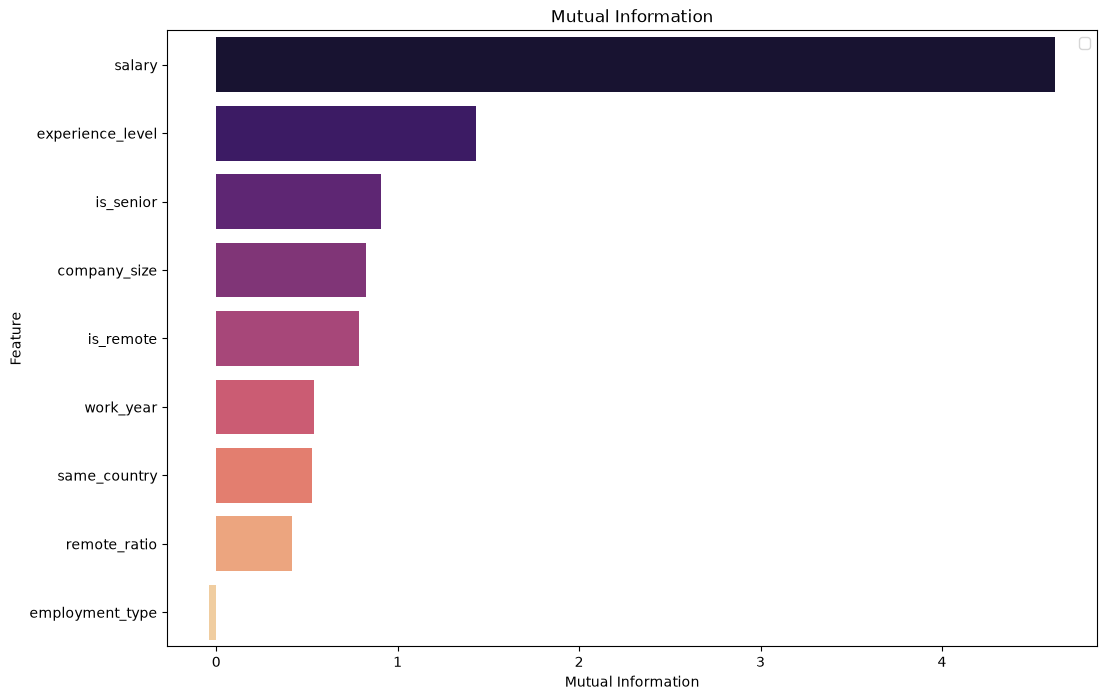

In [34]:
mi_result(12, 8, dataset_clean[all_cols], dataset_clean[target_col], "Mutual Information No Duplicated")

##### Method Chi Square

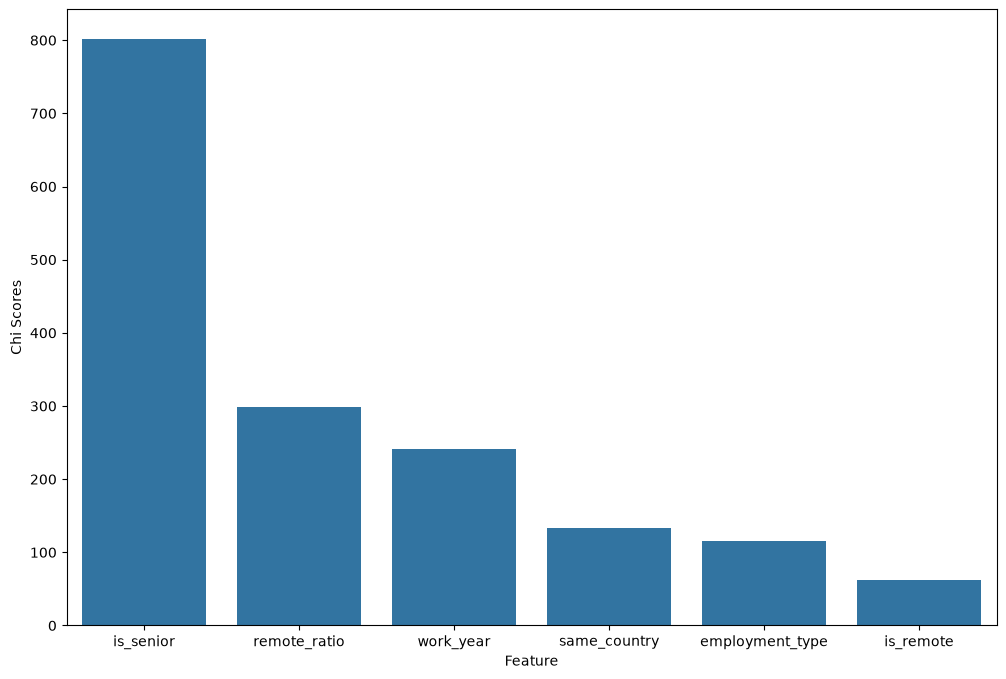

In [35]:
cs_result(15, 8, dataset_clean, all_cols, "Chi Square No Duplicated")

#### *d. Inspeksi Outlier Clean*

<Axes: xlabel='salary_category', ylabel='work_year'>

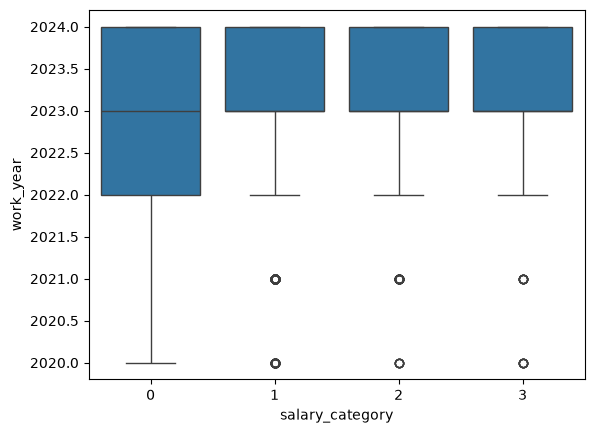

In [36]:
sns.boxplot(data=dataset_clean, x='salary_category', y='work_year')

### 2. Scaling Dataset

In [37]:
means = dataset[num_cols].mean().values
stds = dataset[num_cols].std().values
stds = np.where(stds == 0, 1, stds)

dataset_scaled = dataset_clean.copy()
dataset_scaled [num_cols] = (dataset_clean[num_cols].values - means) / stds
dataset_clean = dataset_scaled
dataset_clean[num_cols].describe()

,employment_type,same_country,is_remote,is_senior,work_year,remote_ratio
count,6132.000000,6132.000000,6132.000000,6132.000000,6132.000000,6132.000000
unique,4.000000,2.000000,2.000000,2.000000,5.000000,3.000000
top,-0.083278,0.114109,-0.762615,0.771233,-0.290448,-0.752806
freq,6056.000000,6006.000000,3630.000000,3664.000000,2591.000000,3630.000000


### 3. Data Imbalance

In [38]:
dataset_clean['salary_category'].value_counts(normalize=True)*100

salary_category
1    51.712329
2    32.844097
3     9.001957
0     6.441618
Name: proportion, dtype: float64

# ***D. Splitting Dataset***

In [39]:
def stratified_split(dataset_clean, target_column, training_size=0.8, random_state=42):
    np.random.seed(random_state)
    train_list, test_list = [], []

    for class_value in dataset_clean[target_column].unique():
        class_data = dataset_clean[dataset_clean[target_column] == class_value]
        class_data = class_data.sample(frac=1, random_state=random_state)

        split_idx = int(len(class_data) * training_size)
        train_list.append(class_data.iloc[:split_idx])
        test_list.append(class_data.iloc[split_idx:])

    train_set = pd.concat(train_list).reset_index(drop=True)
    test_set = pd.concat(test_list).reset_index(drop=True)
    return train_set, test_set

dataset_training, dataset_testing = stratified_split(dataset_clean, "salary_category")

# ***E. Data Sampling***

In [40]:
class_0 = dataset[dataset['salary_category'] == 0]
class_1 = dataset[dataset['salary_category'] == 1]
class_2 = dataset[dataset['salary_category'] == 2]
class_3 = dataset[dataset['salary_category'] == 3]

print("Sebelum sampling:")
print(f"Kelas 0: {len(class_0)}")
print(f"Kelas 1: {len(class_1)}")
print(f"Kelas 2: {len(class_2)}")
print(f"Kelas 3: {len(class_3)}")

# Target: buat semua kelas jadi minimal 20 data (misal)
target_size = 20

# Oversampling kelas langka dengan duplikasi acak
def oversample_class(df_class, target_n):
    n = len(df_class)
    if n >= target_n:
        return df_class
    # Ambil sampel dengan replacement sampai cukup
    extra_needed = target_n - n
    sampled_extra = df_class.sample(n=extra_needed, replace=True, random_state=42)
    return pd.concat([df_class, sampled_extra], ignore_index=True)

# Undersampling kelas mayoritas
def undersample_class(df_class, target_n):
    n = len(df_class)
    if n <= target_n:
        return df_class
    return df_class.sample(n=target_n, replace=False, random_state=42)

# Terapkan
class_0_bal = oversample_class(class_0, target_size)
class_3_bal = oversample_class(class_3, target_size)
class_2_bal = oversample_class(class_2, target_size)  # opsional, tapi biar seimbang
class_1_bal = undersample_class(class_1, target_size)  # kurangi dari 51 → 20

# Gabungkan kembali
dataset_balanced = pd.concat([
    class_0_bal,
    class_1_bal,
    class_2_bal,
    class_3_bal
], ignore_index=True)

# Acak urutan
dataset_balanced = dataset_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nSetelah sampling:")
print(dataset_balanced['salary_category'].value_counts().sort_index())

Sebelum sampling:
Kelas 0: 465
Kelas 1: 5264
Kelas 2: 3605
Kelas 3: 779

Setelah sampling:
salary_category
0     465
1      20
2    3605
3     779
Name: count, dtype: int64


# ***F. Feature Target Declaration***

In [41]:
X_train = dataset_training[feature_cols].to_numpy()
X_test = dataset_testing[feature_cols].to_numpy()
y_train = dataset_training['salary_category'].to_numpy()
y_test = dataset_testing['salary_category'].to_numpy()

# **III. Modeling**

# ***A. Model Application***

### 1. Model dengan Class

In [42]:
class TreeEnsemble:
    def __init__(self, max_depth=5, feature_names=None, mode="ensemble", n_trees=10,
                 sample_ratio=0.8, feature_ratio=0.8, min_samples_split=2, min_samples_leaf=1):
        self.max_depth = max_depth
        self.mode = mode
        self.feature_names = feature_names
        self.n_trees = n_trees
        self.sample_ratio = sample_ratio
        self.feature_ratio = feature_ratio
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.trees = [] if self.mode == "ensemble" else None

    def most_common_value(self, arr):
        unique, counts = np.unique(arr, return_counts=True)
        return unique[np.argmax(counts)]

    def entropy(self, y):
        if len(y) == 0:
            return 0
        unique, counts = np.unique(y, return_counts=True)
        probs = counts / len(y)
        # Hindari log(0)
        probs = np.clip(probs, 1e-9, 1.0)
        return -np.sum(probs * np.log2(probs))

    def information_gain(self, parent, left, right):
        if len(left) == 0 or len(right) == 0:
            return 0
        return self.entropy(parent) - (
            len(left) / len(parent) * self.entropy(left) +
            len(right) / len(parent) * self.entropy(right)
        )

    def _build_tree(self, X, y, depth=0):
        # Base case: jika semua label sama
        if len(np.unique(y)) == 1:
            return self.most_common_value(y)

        # Base case: jika terlalu dalam atau jumlah sampel kurang
        if depth >= self.max_depth or len(y) < self.min_samples_split:
            return self.most_common_value(y)

        best_feature, best_split, best_gain = None, None, -1
        n_features_to_check = int(X.shape[1] * self.feature_ratio) if self.mode == "ensemble" else X.shape[1]
        feature_indices = np.random.choice(X.shape[1], size=n_features_to_check, replace=False)

        for feature in feature_indices:
            unique_values = np.unique(X[:, feature])
            for value in unique_values:
                left_mask = X[:, feature] <= value
                right_mask = ~left_mask

                if len(y[left_mask]) < self.min_samples_leaf or len(y[right_mask]) < self.min_samples_leaf:
                    continue

                gain = self.information_gain(y, y[left_mask], y[right_mask])
                if gain > best_gain:
                    best_feature, best_split, best_gain = feature, value, gain

        if best_feature is None:
            return self.most_common_value(y)

        left_mask = X[:, best_feature] <= best_split
        right_mask = ~left_mask

        return {
            "feature": best_feature,
            "split": best_split,
            "left": self._build_tree(X[left_mask], y[left_mask], depth + 1),
            "right": self._build_tree(X[right_mask], y[right_mask], depth + 1),
        }

    def fit(self, X, y):
        if self.mode == "single":
            self.trees = self._build_tree(X, y)
        else:
            self.trees = []
            n_samples = int(len(X) * self.sample_ratio)
            n_features = int(X.shape[1] * self.feature_ratio)

            for _ in range(self.n_trees):
                # Bootstrap sampling (dengan replacement)
                sample_idx = np.random.choice(len(X), n_samples, replace=True)
                # Pilih subset fitur acak
                feature_idx = np.random.choice(X.shape[1], n_features, replace=False)
                X_sample, y_sample = X[sample_idx][:, feature_idx], y[sample_idx]
                tree = self._build_tree(X_sample, y_sample)
                self.trees.append((tree, feature_idx))

    def _predict_sample(self, tree, sample):
        if not isinstance(tree, dict):
            return tree
        feature = tree["feature"]
        split = tree["split"]
        if sample[feature] <= split:
            return self._predict_sample(tree["left"], sample)
        else:
            return self._predict_sample(tree["right"], sample)

    def predict(self, X):
        if self.mode == "single":
            return np.array([self._predict_sample(self.trees, sample) for sample in X])

        predictions = []
        for tree, feature_idx in self.trees:
            preds = [self._predict_sample(tree, sample[feature_idx]) for sample in X]
            predictions.append(preds)

        predictions = np.array(predictions)
        # Voting mayoritas
        final_preds = [self.most_common_value(predictions[:, i]) for i in range(predictions.shape[1])]
        return np.array(final_preds)

    def print_tree(self, tree=None, depth=0):
        if tree is None:
            tree = self.trees if self.mode == 'single' else self.trees[0][0]

        if not isinstance(tree, dict):
            print("  " * depth + f"Predict: {tree}")
            return

        feature_name = self.feature_names[tree['feature']] if self.feature_names else f"Feature {tree['feature']}"
        print("  " * depth + f"({feature_name}) <= {tree['split']}")

        print("  " * depth + "-> Left:")
        self.print_tree(tree['left'], depth + 1)

        print("  " * depth + "-> Right:")
        self.print_tree(tree['right'], depth + 1)

    def plot_tree(self, tree=None, x=0.5, y=1, dx=0.25, dy=0.15, ax=None):
        if ax is None:
            fig, ax = plt.subplots(figsize=(15, 10))
        ax.axis("off")

        if tree is None:
            tree = self.trees if self.mode == 'single' else self.trees[0][0]

        def _plot_node(ax, tree, x, y, x_offset, y_offset):
            if not isinstance(tree, dict):
                ax.text(x, y, f"Leaf: {tree}", bbox=dict(facecolor="lightgreen", alpha=0.5), ha='center', va='center')
                return

            feature_name = self.feature_names[tree["feature"]]
            node_text = f"{feature_name} <= {tree['split']}"
            ax.text(x, y, node_text, bbox=dict(facecolor="lightblue", alpha=0.5), ha='center', va='center', fontsize=10)

            x_left, x_right = x - x_offset, x + x_offset
            y_next = y - y_offset

            ax.plot([x, x_left], [y, y_next], 'k-')
            ax.plot([x, x_right], [y, y_next], 'k-')

            ax.text((x + x_left)/2, (y + y_next)/2, "T", color='green', fontsize=10)
            ax.text((x + x_right)/2, (y + y_next)/2, "F", color='red', fontsize=10)

            _plot_node(ax, tree['left'], x_left, y_next, x_offset / 2, y_offset)
            _plot_node(ax, tree['right'], x_right, y_next, x_offset / 2, y_offset)

        _plot_node(ax, tree, x, y, dx, dy)

    def plot_forest(self, num_trees):
        num_trees = min(num_trees, len(self.trees))
        for i in range(num_trees):
            tree, _ = self.trees[i]
            fig, ax = plt.subplots(figsize=(15, 10))
            self.plot_tree(tree, ax=ax)
            plt.title(f"Tree: {i + 1}")
            plt.show()

    def trace_decision_path(self, tree, sample, depth=0):
        if not isinstance(tree, dict):
            print("  " * depth + f"==> Predict: {tree}")
            return tree

        split = tree['split']
        feature = tree['feature']
        decision = "Left" if sample[feature] <= split else "Right"
        print("  " * depth + f"{self.feature_names[feature]} <= {split} -> {decision}")
        next_branch = tree['left'] if sample[feature] <= split else tree['right']
        return self.trace_decision_path(next_branch, sample, depth + 1)

    def predict_with_trace(self, X):
        predictions = []
        for i, sample in enumerate(X):
            print(f"\nSample: {i + 1}")
            if self.mode == 'single':
                pred = self.trace_decision_path(self.trees, sample)
            else:
                tree_pred = []
                for j, (tree, feature_idx) in enumerate(self.trees):
                    print(f"\nTree: {j + 1}")
                    reduced_sample = np.array(sample)[feature_idx]
                    tree_pred.append(self.trace_decision_path(tree, reduced_sample))
                pred = self.most_common_value(tree_pred)
                print(f"Majority Vote: {pred}")
            predictions.append(pred)
        return np.array(predictions)

### 2. Pengaplikasian Model

In [43]:
# Siapkan data
feature_cols = [
    'experience_level', 'company_size', 'is_senior',
    'is_remote', 'work_year', 'same_country', 'remote_ratio'
]
feature_cols = [col for col in feature_cols if col in dataset_balanced.columns]

X = dataset_balanced[feature_cols].values
y = dataset_balanced['salary_category'].values

# Split manual
def train_test_split_manual(X, y, test_size=0.3, random_state=42):
    np.random.seed(random_state)
    indices = np.random.permutation(len(X))
    split = int(len(X) * (1 - test_size))
    train_idx, test_idx = indices[:split], indices[split:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

X_train, X_test, y_train, y_test = train_test_split_manual(X, y, test_size=0.3)

# Buat Random Forest
rf = TreeEnsemble(
    mode="ensemble",
    n_trees=15,            # cukup untuk dataset kecil
    max_depth=4,           # hindari overfit
    min_samples_split=3,   # setidaknya 3 data untuk split
    min_samples_leaf=2,    # setidaknya 2 data di leaf
    sample_ratio=0.8,
    feature_ratio=0.7,     # pilih subset fitur acak per split
    feature_names=feature_cols
)

# Latih model
rf.fit(X_train, y_train)

# ***B. Visualisasi Model***

### 1. Distribusi Hasil Prediksi

In [44]:
y_pred_train = rf.predict(X_train)
y_pred_test = rf.predict(X_test)

def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

#### *a. Training Model*

In [45]:
data_pred_train = pd.DataFrame({"Train Accuracy:", accuracy(y_train, y_pred_train)})

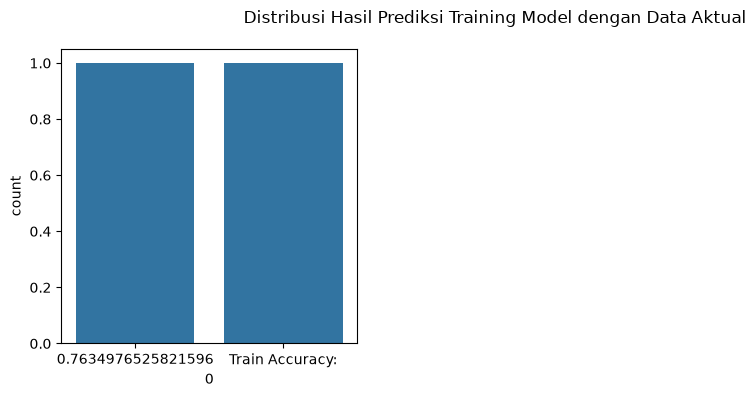

In [46]:
plt.figure(figsize=(10, 4))

for i, col in enumerate(data_pred_train):
    plt.subplot(1, 3, i+1)
    sns.countplot(x=data_pred_train[col])

plt.suptitle("Distribusi Hasil Prediksi Training Model dengan Data Aktual")
plt.tight_layout()
plt.show()

#### *b. Testing Model*

In [47]:
data_pred_test = pd.DataFrame({"Test Accuracy:", accuracy(y_test, y_pred_test)})

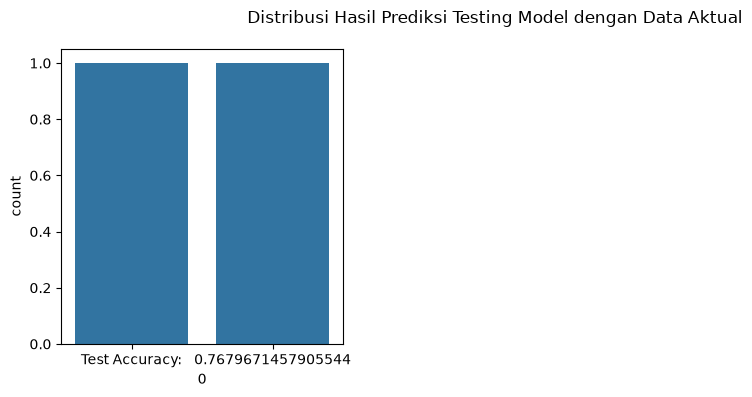

In [48]:
plt.figure(figsize=(10, 4))

for i, col in enumerate(data_pred_test):
    plt.subplot(1, 3, i+1)
    sns.countplot(x=data_pred_test[col])

plt.suptitle("Distribusi Hasil Prediksi Testing Model dengan Data Aktual")
plt.tight_layout()
plt.show()

### 2. Confusion Matrix

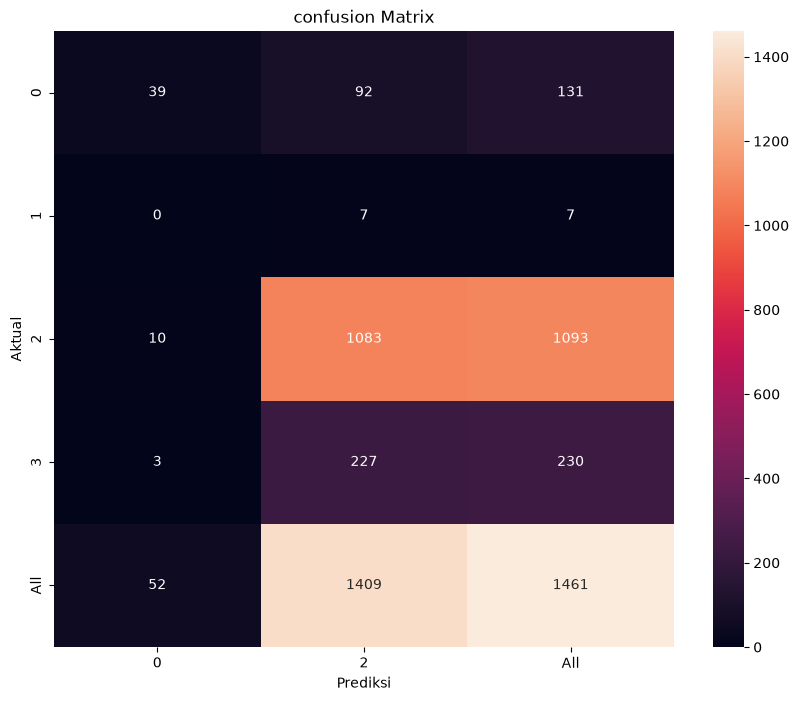

,0,2,All
0,39,92,131
1,0,7,7
2,10,1083,1093
3,3,227,230
All,52,1409,1461


In [49]:
data_confusion = pd.crosstab(y_test, y_pred_test, margins=True)
data_confusion.columns = data_confusion.columns.tolist()
data_confusion.index = data_confusion.index.tolist()

plt.figure(figsize=(10,8))
plt.title("confusion Matrix")
sns.heatmap(data_confusion, annot=True, fmt="d")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

display(data_confusion)

### 3. Visualisasi Pohon

<Figure size 1500x1000 with 0 Axes>

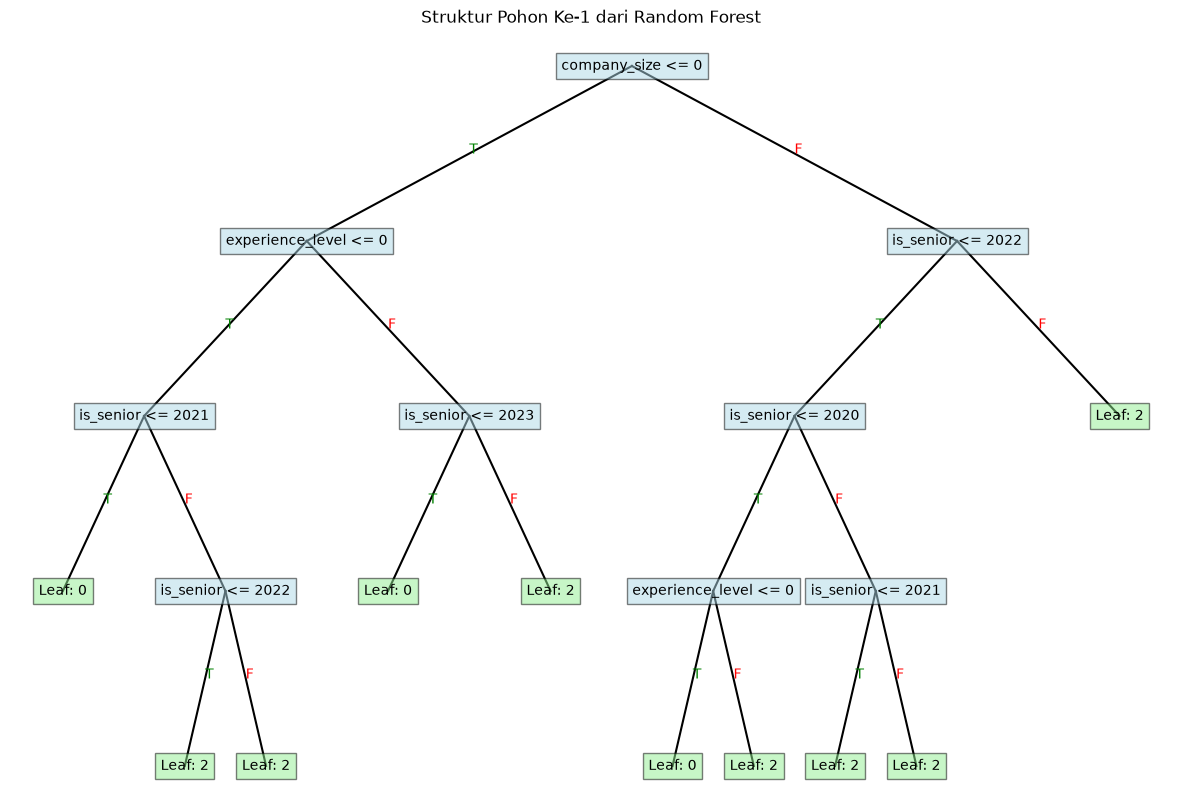

In [50]:
# Plot satu pohon pertama
plt.figure(figsize=(15, 10))
rf.plot_tree(tree=rf.trees[0][0])  # trees[0][0] = pohon pertama
plt.title("Struktur Pohon Ke-1 dari Random Forest")
plt.show()

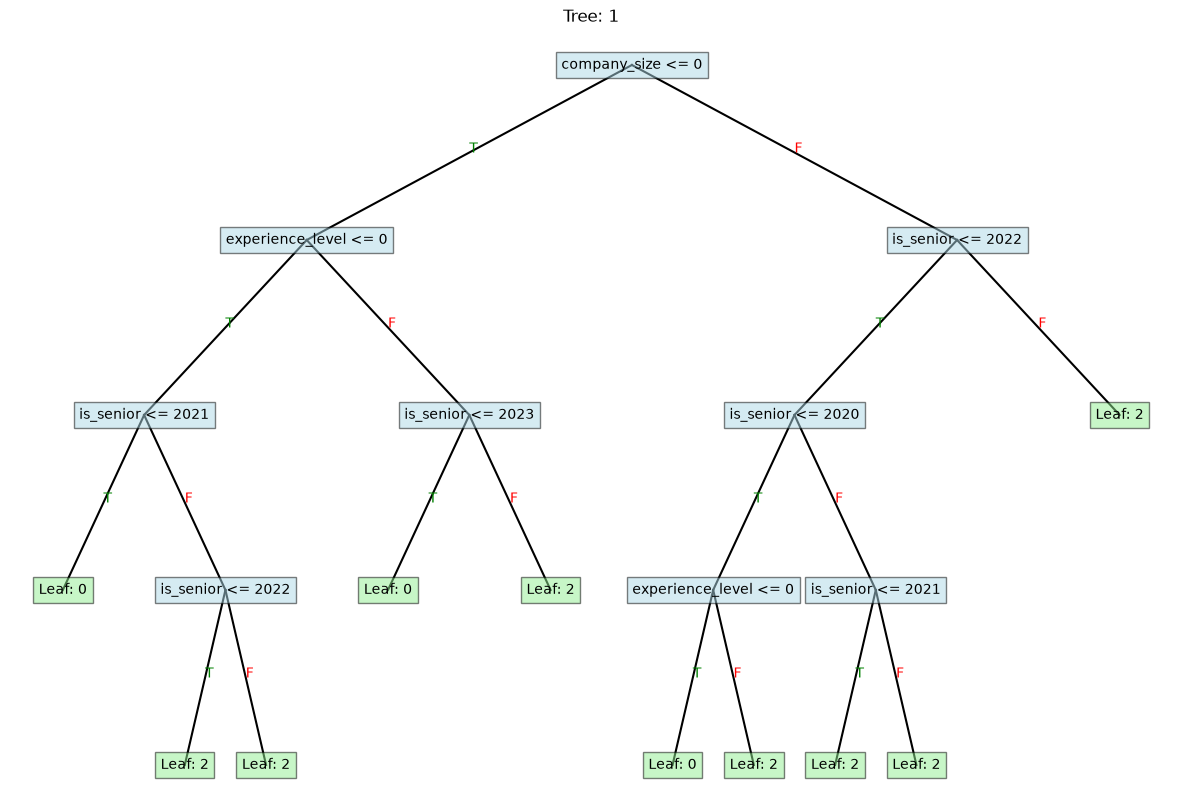

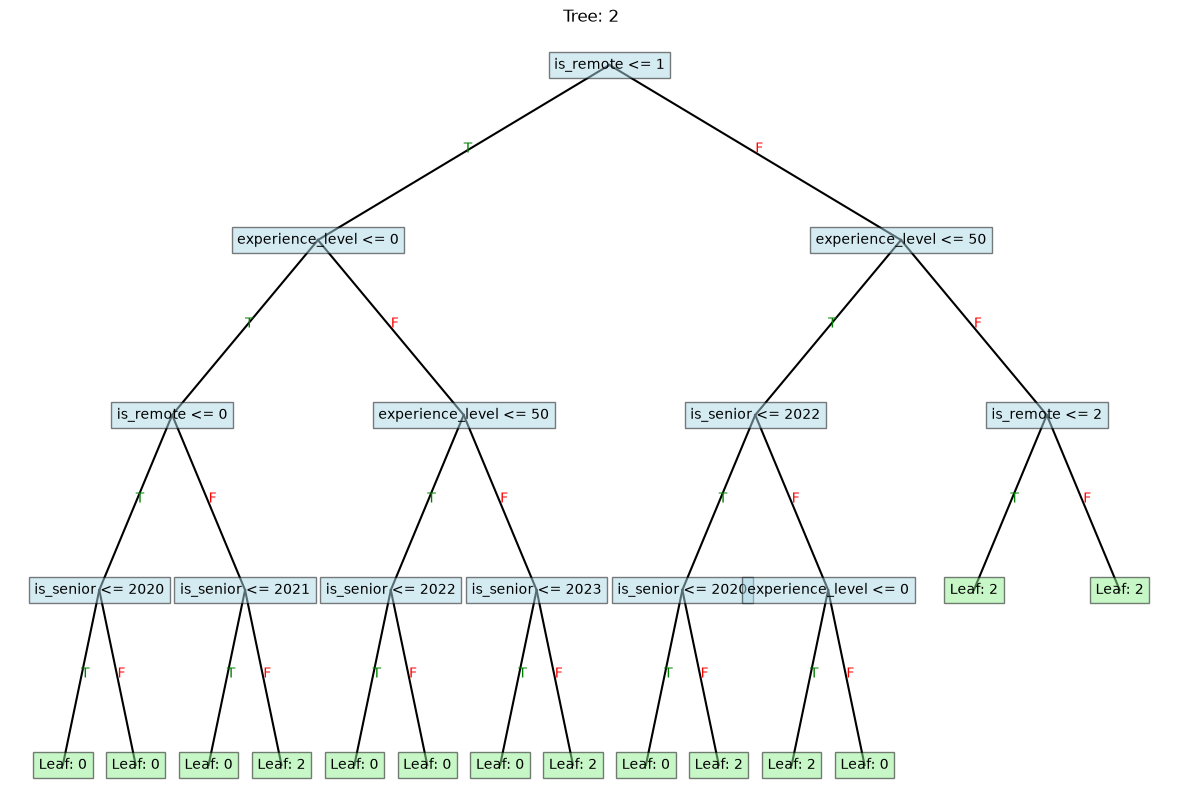

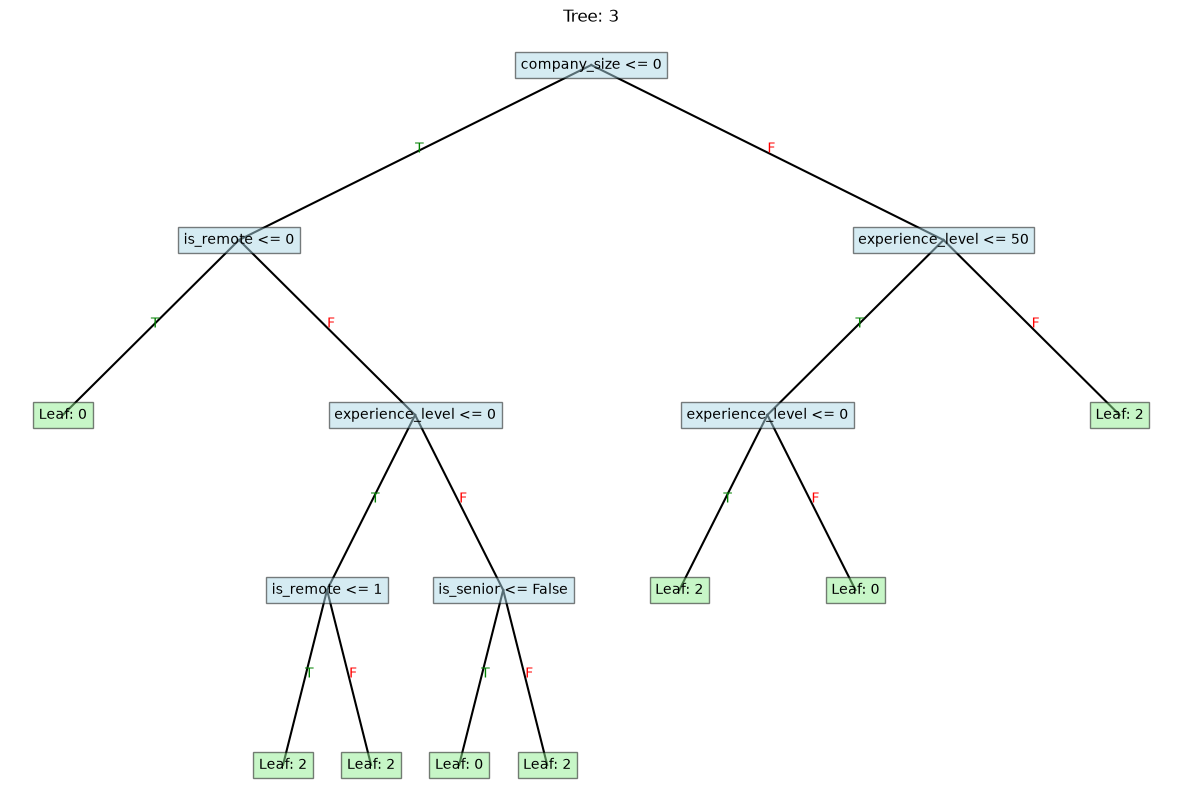

In [51]:
rf.plot_forest(num_trees=3)

### 4. Tracing Path

In [52]:
sample = X_test[0]
pred = rf.trace_decision_path(rf.trees[0][0], sample)  

company_size <= 0 -> Right
  is_senior <= 2022 -> Left
    is_senior <= 2020 -> Left
      experience_level <= 0 -> Right
        ==> Predict: 2


# ***C. Evaluasi Model***

### 1. Evaluation Metric

In [53]:
def evaluation_metric(y_true, y_pred, average):
    accuracy_list, precision_list, recall_list, f1_list = [], [], [], []
    labels = np.unique(y_true)

    for label in labels:
        TP = np.sum((y_true == label) & (y_pred == label))
        FP = np.sum((y_true != label) & (y_pred == label))

        TN = np.sum((y_true != label) & (y_pred != label))
        FN = np.sum((y_true == label) & (y_pred != label))

        accuracy = (TP + TN) / (TP + TN + FP + FN) * 100 if  (TP + TN + FP + FN) != 0 else 0
        precision = TP / (TP + FP) if  (TP + FP)  != 0 else 0
        recall = TP / (TP + FN) if (TP + FN) != 0 else 0
        f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

        accuracy_list.append(accuracy)
        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1_score)

    if average == 'macro':
        accuracy = np.mean(accuracy_list)
        precision = np.mean(precision_list)
        recall = np.mean(recall_list)
        f1_score = np.mean(f1_list)

    elif average == 'micro':
        TP = np.sum(y_true == y_pred)
        FP = np.sum((y_true != y_pred) & (y_pred != y_true))

        TN = np.sum(y_true == y_pred)
        FN = np.sum((y_true == y_pred) & (y_true != y_pred))

        accuracy = (TP + TN) /  (TP + TN + FP + FN) * 100 if  (TP + TN + FP + FN) != 0 else 0
        precision = TP / (TP + FP) if  (TP + FP)  != 0 else 0
        recall = TP / (TP + FN) if (TP + FN) != 0 else 0
        f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

    return accuracy, precision, recall, f1_score

#### *a. Training Model*

In [54]:
accuracy_forest_train, precision_forest_train, recall_forest_train, f1_score_forest_train = evaluation_metric(y_train, y_pred_train, average='micro')

print("-----------------------------------------------------------------")
print(f"Akurasi Random Forest Train: {accuracy_forest_train:.2f}")
print("-----------------------------------------------------------------")
print(f"Presisi Random Forest Train: {precision_forest_train:.2f}")
print("-----------------------------------------------------------------")
print(f"Recall Random Forest Train: {recall_forest_train:.2f}")
print("-----------------------------------------------------------------")
print(f"F1 Score Random Forest Train: {f1_score_forest_train:.2f}")
print("-----------------------------------------------------------------")

-----------------------------------------------------------------
Akurasi Random Forest Train: 86.59
-----------------------------------------------------------------
Presisi Random Forest Train: 0.76
-----------------------------------------------------------------
Recall Random Forest Train: 1.00
-----------------------------------------------------------------
F1 Score Random Forest Train: 0.87
-----------------------------------------------------------------


#### *b. Testing Model*

In [55]:
accuracy_forest_test, precision_forest_test, recall_forest_test, f1_score_forest_test = evaluation_metric(y_test ,y_pred_test, average='micro')

print("-----------------------------------------------------------------")
print(f"Akurasi Random Forest Test: {accuracy_forest_test:.2f}")
print("-----------------------------------------------------------------")
print(f"Presisi Random Forest Test: {precision_forest_test:.2f}")
print("-----------------------------------------------------------------")
print(f"Recall Random Forest Test: {recall_forest_test:.2f}")
print("-----------------------------------------------------------------")
print(f"F1 Score Random Forest Test: {f1_score_forest_test:.2f}")
print("-----------------------------------------------------------------")

-----------------------------------------------------------------
Akurasi Random Forest Test: 86.88
-----------------------------------------------------------------
Presisi Random Forest Test: 0.77
-----------------------------------------------------------------
Recall Random Forest Test: 1.00
-----------------------------------------------------------------
F1 Score Random Forest Test: 0.87
-----------------------------------------------------------------


### 2. Bias and Variance Model

In [56]:
bias = 100 - accuracy_forest_test
variance = accuracy_forest_train - accuracy_forest_test
data = {
    'Metric' : ['Bias', 'Variance'],
    'Value' : [bias, variance]
}

data_eval_forest = pd.DataFrame(data)

C:\Users\nizam\AppData\Local\Temp\ipykernel_640\584593605.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_eval_forest, x='Metric', y='Value', palette='coolwarm')


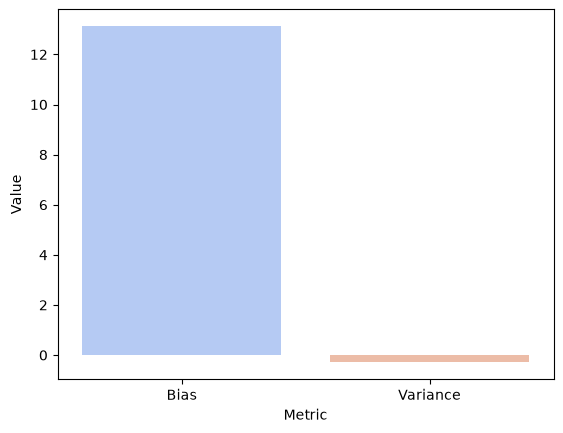

In [57]:
sns.barplot(data=data_eval_forest, x='Metric', y='Value', palette='coolwarm')
plt.show()

### 3. K-Fold

In [58]:
def accuracy_manual(y_true, y_pred):
    return np.mean(y_true == y_pred)

def stratified_k_fold(X, y, model, k=5, random_state=42):
    np.random.seed(random_state)
    unique_classes, counts = np.unique(y, return_counts=True)
    class_indices = {cls: np.where(y == cls)[0] for cls in unique_classes}
    folds = [[] for _ in range(k)]

    for cls, indices in class_indices.items():
        np.random.shuffle(indices)
        fold_sizes = np.array_split(indices, k)
        for i in range(k):
            folds[i].extend(fold_sizes[i])

    accuracies = []

    for i in range(k):
        test_idx = np.array(folds[i])
        train_idx = np.hstack([folds[j] for j in range(k) if j != i])

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Latih model
        model.fit(X_train, y_train)
        # Prediksi
        y_pred = model.predict(X_test)

        # Akurasi manual
        accuracy = accuracy_manual(y_test, y_pred)
        accuracies.append(accuracy)

        print(f"Fold {i + 1}: Accuracy = {accuracy:.2f}")

    avg_acc = np.mean(accuracies)
    std_dev = np.std(accuracies)

    print(f"\nAverage Accuracy: {avg_acc:.2f}")
    print(f"Standard Deviation: {std_dev:.2f}")

    return avg_acc, std_dev

In [59]:
k_fold_forest_train = stratified_k_fold(X_test, y_test, rf, k=5)

Fold 1: Accuracy = 0.77
Fold 2: Accuracy = 0.77
Fold 3: Accuracy = 0.76
Fold 4: Accuracy = 0.79
Fold 5: Accuracy = 0.77

Average Accuracy: 0.77
Standard Deviation: 0.01


# **IV. GUI**

In [60]:
# input dropdown

root = tk.Tk()
root.title("Salary Prediction System")
root.geometry("450x550")
root.configure(bg="#f5f5f5")

header = tk.Label(root, text="Salary Predictor", font=("Arial", 18, "bold"), bg="#34495e", fg="white", pady=12)
header.pack(fill="x")

main_frame = tk.Frame(root, bg="#f5f5f5", pady=50)
main_frame.pack()

dropdown_vars = {}

dropdown_options = {
    'experience_level': {
        'label': 'Experience Level',
        'options': ['Entry (0)', 'Mid (1)', 'Senior (2)', 'Expert (3)'],
        'values': [0, 1, 2, 3]
    },
    'company_size': {
        'label': 'Company Size',
        'options': ['Small (0)', 'Medium (1)', 'Large (2)'],
        'values': [0, 1, 2]
    },
    'is_senior': {
        'label': 'Is Senior',
        'options': ['No (0)', 'Yes (1)'],
        'values': [0, 1]
    },
    'is_remote': {
        'label': 'Is Remote',
        'options': ['No (0)', 'Yes (1)'],
        'values': [0, 1]
    },
    'work_year': {
        'label': 'Work Year',
        'options': ['2020', '2021', '2022', '2023', '2024'],
        'values': [2020, 2021, 2022, 2023, 2024]
    },
    'same_country': {
        'label': 'Same Country',
        'options': ['No (0)', 'Yes (1)'],
        'values': [0, 1]
    },
    'remote_ratio': {
        'label': 'Remote Ratio',
        'options': ['0%', '50%', '100%'],
        'values': [0, 50, 100]
    }
}

for i, col in enumerate(feature_cols):
    label = tk.Label(main_frame, text=dropdown_options[col]['label'], font=("Arial", 11, "bold"), bg="#f5f5f5", width=15, anchor="w")
    label.grid(row=i, column=0, pady=8, padx=10, sticky="w")

    var = tk.StringVar(root)
    var.set(dropdown_options[col]['options'][0])
    dropdown_vars[col] = var

    menu = tk.OptionMenu(main_frame, var, *dropdown_options[col]['options'])
    menu.config(width=18, font=("Arial", 10), bg="white", activebackground="#3498db", cursor="hand2")
    menu.grid(row=i, column=1, pady=8, padx=10)

result_frame = tk.Frame(root, bg="#ecf0f1", relief="ridge", bd=2)
result_frame.pack(fill="x", padx=30, pady=20)

result_title = tk.Label(result_frame, text="Prediction Result", font=("Arial", 12, "bold"), bg="#ecf0f1", fg="#2c3e50")
result_title.pack(pady=10)

result_label = tk.Label(result_frame, text="Select options and click predict", font=("Arial", 11), bg="#ecf0f1", fg="#7f8c8d", height=2)
result_label.pack(pady=5)

def predict_salary():
    try:
        input_values = []
        for col in feature_cols:
            selected = dropdown_vars[col].get()
            idx = dropdown_options[col]['options'].index(selected)
            value = dropdown_options[col]['values'][idx]
            input_values.append(value)

        X_gui = np.array(input_values).reshape(1, -1)
        prediction = rf.predict(X_gui)[0]

        salary_categories = {
            0: ("LOW SALARY", "< $50,000", "#e74c3c"),
            1: ("MEDIUM SALARY", "$50,000 - $150,000", "#f39c12"),
            2: ("HIGH SALARY", "$150,000 - $250,000", "#3498db"),
            3: ("VERY HIGH SALARY", "> $250,000", "#27ae60")
        }

        category, range_text, color = salary_categories[prediction]

        result_label.config(text=f"{category}\n{range_text}", fg=color, font=("Arial", 12, "bold"))
    
    except Exception as e:
        result_label.config(text="Error in prediction", fg="#e74c3c")

def reset_all():
    for col in feature_cols:
        dropdown_vars[col].set(dropdown_options[col]['options'][0])
    result_label.config(text="Select options and click predict", fg="#7f8c8d", font=("Arial", 11))

button_frame = tk.Frame(root, bg="#f5f5f5")
button_frame.pack()

predict_btn = tk.Button(button_frame, text="PREDICT", command=predict_salary, font=("Arial", 11, "bold"), bg="#3498db", fg="white", width=12, pady=8, cursor="hand2", relief="raised", bd=2)
predict_btn.grid(row=0, column=1, padx=10)

footer = tk.Label(root, text="SMKN 8 Malang", font=("Arial", 9), bg="#f5f5f5", fg="#95a5a6")
footer.pack(side="bottom", pady=10)

root.mainloop()

In [61]:
# input manual

root = tk.Tk()
root.title("Salary Prediction System")
root.geometry("500x600")
root.configure(bg="#f0f0f0")

# Header
header = tk.Label(root, text="SALARY PREDICTOR", font=("Arial", 20, "bold"), 
                  bg="#2c3e50", fg="white", pady=15)
header.pack(fill="x")

# Frame untuk input
input_frame = tk.Frame(root, bg="#f0f0f0", pady=20)
input_frame.pack()

# Dictionary untuk menyimpan input
inputs = {}

# Label dan Entry untuk setiap feature
features_info = [
    ("Experience Level", "0=EN, 1=MI, 2=SE, 3=EX"),
    ("Company Size", "0=Small, 1=Medium, 2=Large"),
    ("Is Senior", "0=No, 1=Yes"),
    ("Is Remote", "0=No, 1=Yes"),
    ("Work Year", "Enter year (e.g., 2024)"),
    ("Same Country", "0=No, 1=Yes"),
    ("Remote Ratio", "0-100")
]

for i, (feature, hint) in enumerate(features_info):
    # Label feature
    label = tk.Label(input_frame, text=feature, font=("Arial", 11, "bold"),
                     bg="#f0f0f0", anchor="w")
    label.grid(row=i*2, column=0, sticky="w", pady=5)
    
    # Hint text
    hint_label = tk.Label(input_frame, text=hint, font=("Arial", 9),
                         bg="#f0f0f0", fg="#7f8c8d", anchor="w")
    hint_label.grid(row=i*2, column=1, sticky="w", padx=10)
    
    # Entry field
    entry = tk.Entry(input_frame, width=15, font=("Arial", 10))
    entry.grid(row=i*2, column=2, pady=5)
    inputs[feature_cols[i]] = entry

# Frame untuk hasil
result_frame = tk.Frame(root, bg="#ecf0f1", pady=20)
result_frame.pack(fill="x", padx=20)

# Label hasil prediksi
result_label = tk.Label(result_frame, text="Prediction Result", 
                       font=("Arial", 12, "bold"), bg="#ecf0f1")
result_label.pack()

result_text = tk.Label(result_frame, text="Enter data and click Predict", 
                      font=("Arial", 11), bg="#ecf0f1", fg="#34495e")
result_text.pack(pady=10)

# Fungsi prediksi
def predict_salary():
    try:
        # Ambil nilai dari input
        input_values = []
        for col in feature_cols:
            value = float(inputs[col].get())
            input_values.append(value)
        
        # Reshape untuk prediksi
        X_gui = np.array(input_values).reshape(1, -1)
        
        # Prediksi menggunakan model
        prediction = rf.predict(X_gui)[0]
        
        # Mapping hasil
        salary_map = {
            0: "Low (<$50K)",
            1: "Medium ($50K-$150K)",
            2: "High ($150K-$250K)",
            3: "Very High (>$250K)"
        }
        
        # Update hasil
        result_text.config(text=f"Predicted Salary: {salary_map[prediction]}",
                          fg="#27ae60", font=("Arial", 12, "bold"))
        
        # Tambah confidence indicator (simulasi)
        confidence = np.random.uniform(75, 95)
        confidence_label.config(text=f"Confidence: {confidence:.1f}%")
        
    except ValueError:
        result_text.config(text="Please enter valid numbers!", fg="#e74c3c")
    except Exception as e:
        result_text.config(text="Error in prediction!", fg="#e74c3c")

# Confidence label
confidence_label = tk.Label(result_frame, text="", font=("Arial", 10),
                           bg="#ecf0f1", fg="#7f8c8d")
confidence_label.pack()

# Tombol prediksi
predict_btn = tk.Button(root, text="PREDICT", command=predict_salary,
                       font=("Arial", 12, "bold"), bg="#3498db", fg="white",
                       padx=30, pady=10, cursor="hand2")
predict_btn.pack(pady=20)

# Fungsi reset
def reset_form():
    for entry in inputs.values():
        entry.delete(0, tk.END)
    result_text.config(text="Enter data and click Predict", fg="#34495e")
    confidence_label.config(text="")

# Tombol reset
reset_btn = tk.Button(root, text="RESET", command=reset_form,
                     font=("Arial", 10), bg="#95a5a6", fg="white",
                     padx=20, pady=5, cursor="hand2")
reset_btn.pack()

# Footer
footer = tk.Label(root, text="© 2025 Salary Prediction System",
                 font=("Arial", 9), bg="#f0f0f0", fg="#7f8c8d")
footer.pack(side="bottom", pady=10)

root.mainloop()